J25 - Projet pratique 3 : Series temporelles

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Heure 1 : Audit et preparation temporelle

In [42]:
#1
df = pd.read_csv("J25_dataset_series_temporelles.csv")
df
#2
df.shape
df.dtypes
df["date"] = pd.to_datetime(df["date"] , format = "mixed", dayfirst = True)
df["date"].min()
df["date"].max()
#3
somme_nul = df.isna().sum()
pourcentage = (somme_nul * 100) / len(df)
pourcentage.round(2)
#4
df[df.duplicated()]
df = df.drop_duplicates()
#5
df["channel"] = df["channel"].replace({"APP":"App",
    "WEB" : "Web",
     "Marketplac" : "Marketplace",
     "Market Place" : "Marketplace",
     "Market place" : "Marketplace",
     "Ap" : "App"})
df["promo_day"] = df["promo_day"].replace({"YES" : "Oui",
        "yes" : "Oui" , "YeS" : "Oui", "yeS" : "Oui" })
df["campaign"] = df["campaign"].replace({"Non" : "None",
    "Back To School" : "Back to School", 
    "Sumer Sale" : "Summer Sale" , "Summer Sal" : "Summer Sale",
    "Ramadane" : "Ramadan"                                  })
#6
df["channel"] = df["channel"].str.title().str.strip()
df["promo_day"] = df["promo_day"].str.title().str.strip()
df["campaign"] = df["campaign"].str.strip()
#7
df["date"] = pd.to_datetime(df["date"] , format = "mixed", dayfirst = True)
df = df.sort_values(by="date", ascending=True)
#8
df.describe()
df[df["orders"] > df["sessions"]]
df[df["returned_orders"] > df["orders"]]
df[df["returns_mad"] > df["gross_revenue_mad"]]
df[df["ad_spend_mad"] < 0]
#9
df.isna().sum()
df["channel"] = df["channel"].fillna("Inconnue") #valeur categorielle
df["sessions"] = df["sessions"].fillna(df["sessions"].median()) #valeur numerique
df["returns_mad"] = df["returns_mad"].fillna(df["returns_mad"].median()) #valeur numerique
df["ad_spend_mad"] = df["ad_spend_mad"].fillna(df["ad_spend_mad"].median()) #valeur numerique
df["new_customers"] = df["new_customers"].fillna(df["new_customers"].median()) #valeur numerique
df["campaign"] = df["campaign"].fillna("None") #valeur categorielle
#10
df["net_revenue_mad"] =  df["gross_revenue_mad"] - df["discounts_mad"] - df["returns_mad"]
df["conversion_rate_pct"] =   (df["orders"] / df["sessions"]) * 100
df["avg_order_value_mad"] = df["net_revenue_mad"] / df["orders"]
df["return_rate_pct"] = (df["returned_orders"] / df["orders"] ) * 100
df["roas"] = df["net_revenue_mad"] / df["ad_spend_mad"]

df.loc[df["orders"] > df["sessions"], "conversion_rate_pct"] = np.nan
df.loc[df["returned_orders"] > df["orders"],"return_rate_pct"] = np.nan
df.loc[df["ad_spend_mad"] <= 0, "roas"] = np.nan
#Verification globale :
df.isna().sum().sum()
df.duplicated().sum()
df.info()

<class 'pandas.DataFrame'>
Index: 1824 entries, 1089 to 231
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   record_id            1824 non-null   str           
 1   date                 1824 non-null   datetime64[us]
 2   channel              1824 non-null   str           
 3   sessions             1824 non-null   float64       
 4   orders               1824 non-null   int64         
 5   units_sold           1824 non-null   int64         
 6   gross_revenue_mad    1824 non-null   float64       
 7   discounts_mad        1824 non-null   float64       
 8   returned_orders      1824 non-null   int64         
 9   returns_mad          1824 non-null   float64       
 10  ad_spend_mad         1824 non-null   float64       
 11  new_customers        1824 non-null   float64       
 12  promo_day            1824 non-null   str           
 13  campaign             1824 non-null   str       

Heure 2 : Analyse temporelle et saisonnalite

In [44]:
df["channel"] = df["channel"].replace({
     "Marketplac" : "Marketplace",
     "Market Place" : "Marketplace",
     "Market place" : "Marketplace",})
#1
journalier = df.groupby("date").agg(
    sessions=("sessions", "sum"),
    orders=("orders", "sum"),
    ad_spend_mad=("ad_spend_mad", "sum"),
    net_revenue_mad=("net_revenue_mad", "sum"))
journalier
#2
df["year_month"] = df["date"].dt.to_period("M")

Les_mois = df.groupby("year_month").agg(
    sessions=("sessions", "sum"),
    orders=("orders", "sum"),
    ad_spend_mad=("ad_spend_mad", "sum"),
    net_revenue_mad=("net_revenue_mad", "sum"))

Les_mois["conversion_pct"] = (
    Les_mois["orders"] /Les_mois["sessions"]) * 100

Les_mois["panier_moyen"] = (
    Les_mois["net_revenue_mad"] /Les_mois["orders"])

Les_mois["roas"] = (
    Les_mois["net_revenue_mad"] /Les_mois["ad_spend_mad"])

Les_mois.round(2)
#3
Les_mois = Les_mois.sort_values(by = "net_revenue_mad" , ascending= False)
le_meilleur = Les_mois.head(1)
le_pire = Les_mois.tail(1)
#4
Les_mois = Les_mois.sort_index()
Les_mois["ca_evolution_pct"] = (
    Les_mois["net_revenue_mad"].pct_change() * 100)
plus_hausse = Les_mois.sort_values(by = "ca_evolution_pct", ascending= False).head(1)
plus_basse = Les_mois.sort_values(by = "ca_evolution_pct", ascending= False).tail(1)
#5
journalier = df.groupby("date").agg(
    orders=("orders", "sum"),
    net_revenue_mad=("net_revenue_mad", "sum")).reset_index()

journalier["jour_sem"] = journalier["date"].dt.day_name()

comparaison = journalier.groupby("jour_sem").agg(
    commandes_moyennes=("orders", "mean"),
    ca_moyen=("net_revenue_mad", "mean"))

comparaison
#6
trois_can = pd.pivot_table(df,values = "net_revenue_mad", index = "year_month" , columns = "channel",
                            aggfunc = "sum")
trois_can = trois_can.round(2)
#7
ca_par_canal = df.groupby("channel")["net_revenue_mad"].sum()
contribution = ((ca_par_canal / ca_par_canal.sum()) * 100).round(2)
contribution
#8
promo = df.groupby("promo_day").agg(
    sessions=("sessions", "sum"),
    orders=("orders", "sum"),
    net_revenue_mad=("net_revenue_mad", "sum"))
promo["conversion_pct"] = (
    promo["orders"] /promo["sessions"]) * 100
promo["panier_moyen"] = (
    promo["net_revenue_mad"] /promo["orders"])

promo.round(2)
#9
journalier = journalier.sort_values("date")
journalier["moyenne_mobile_7j"] = (journalier["net_revenue_mad"].rolling(7).mean())
#10
les_10 = df.groupby("date")["net_revenue_mad"].sum()
plus_10 = les_10.sort_values(ascending= False).head(10)
plus_10.round(2)
dates_top10 = plus_10.index
df[df["date"].isin(dates_top10)][
    ["date", "promo_day", "campaign"]].drop_duplicates().sort_values("date")
#11
df["net_revenue_mad"].describe()
Q1 = journalier["net_revenue_mad"].quantile(0.25)
Q3 = journalier["net_revenue_mad"].quantile(0.75)

IQR = Q3 - Q1
borne_basse = Q1 - 1.5 * IQR
borne_haute = Q3 + 1.5 * IQR

jours_atypiques = journalier[
    (journalier["net_revenue_mad"] < borne_basse) |
    (journalier["net_revenue_mad"] > borne_haute)]
jours_atypiques

"""describe c'est une fonction tres utile en pandas pour observer les valuers atypiques
On observe qu'il y a une grande difference entre le min et le max avec la moyenne
Donc on ne supprime rien car on ne sait pas si il y a une donnee qui influence le chiffre 
d'affaires , ainsi se sont des donnees reeles , si on les supprime ca sera une erreur"""
#12
df["panier"] = df["net_revenue_mad"] / df["orders"]
Tab_fin = df.groupby("channel").agg({"sessions":"sum", "orders":"sum", 
    "net_revenue_mad" : "sum", "conversion_rate_pct" : "mean" , "panier" : "mean",
   "roas" :"mean", "return_rate_pct" : "mean" })
Tab_fin.round(2)

,sessions,orders,net_revenue_mad,conversion_rate_pct,panier,roas,return_rate_pct
channel,,,,,,,
App,1322233.0,56445,22355651.82,4.23,400.83,8.63,4.78
Inconnue,11829.0,483,231621.09,4.26,492.43,11.14,4.78
Marketplace,670103.0,36378,18582516.05,5.40,517.29,15.36,6.49
Web,1811565.0,60680,28900813.55,3.33,482.57,8.40,4.60


Heure 3 : Visualisations et interpretation

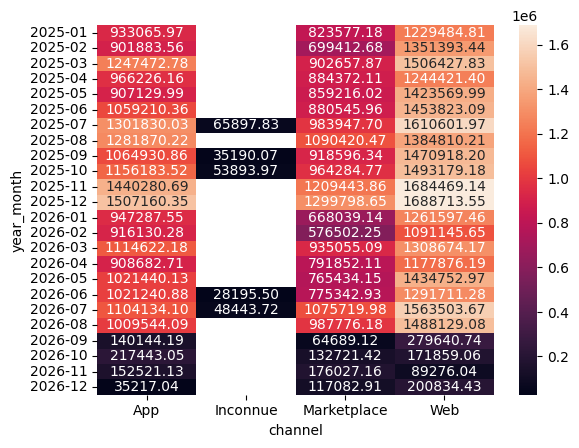

'\nC1 : Le web a le plus sessions et orders parmi tous les channels.\nC2 : Le markerplace a la plus moyenne du panier et du roas et return_rate_pct parmi tous\nles channels.\nC3 : \n'

In [ ]:
#1
sns.lineplot(data=journalier,x="date",y="net_revenue_mad",label="CA journalier")
sns.lineplot(data=journalier,x="date",y="moyenne_mobile_7j",label="Moyenne mobile 7 jours")
plt.title("CA journalier et moyenne mobile sur 7 jours")
plt.show()
#2
Les_mois = df.groupby("year_month").agg(
    sessions=("sessions", "sum"),
    orders=("orders", "sum"),
    ad_spend_mad=("ad_spend_mad", "sum"),
    net_revenue_mad=("net_revenue_mad", "sum")).reset_index()
Les_mois["year_month"] = Les_mois["year_month"].astype(str)
sns.lineplot(data = Les_mois, x = "year_month", y = "net_revenue_mad" ,  marker = "o",label = "CA")
sns.lineplot(data = Les_mois, x = "year_month", y = "orders" ,marker = "o",label = "Commandes")
plt.show()
#3
Tableau = pd.pivot_table(df , values = "net_revenue_mad", index = "year_month",columns = "channel",
    aggfunc = "sum")
sns.heatmap(Tableau, annot = True , fmt = ".2f")
plt.show()
#4
comparaison = comparaison.reset_index()
sns.barplot(data=comparaison,x="jour_sem",y="ca_moyen")
plt.xticks(rotation=45)
sns.barplot(data=comparaison,x="jour_sem",y="commandes_moyennes")
plt.xticks(rotation=45)
plt.show()
#5
promo_graph = promo.reset_index()
sns.barplot(data=promo_graph,x="promo_day",y="conversion_pct")
plt.show()
#6
Les_mois_channel = (
    df.groupby(["year_month", "channel"]).agg(
        net_revenue_mad=("net_revenue_mad", "sum"),ad_spend_mad=("ad_spend_mad", "sum")).reset_index())
Les_mois_channel["roas"] = (Les_mois_channel["net_revenue_mad"] / Les_mois_channel["ad_spend_mad"])
Les_mois_channel["year_month"] = Les_mois_channel["year_month"].astype(str)
sns.lineplot(data= Les_mois_channel,  x = "year_month", y= "roas", hue = "channel", marker = "o")
plt.xticks(rotation = 45)
plt.title("l'evolution mensuelle du ROAS pour chacun des canaux")
plt.tight_layout(rect = [0,0,1,0.95])
plt.show()
#7
"""
C1 : Le Web est le premier canal avec environ 1,81 million de sessions et 60 680 commandes.
C2 : Le markerplace a la plus moyenne du panier et du roas et return_rate_pct parmi tous
les channels.
C3 : On constate que Le web a arrivee a sa plus CA total dans decembre 2025 qui est la plus
CA total dans tous les mois du 2025 et 2026 dans tous les channels 
C4 : il y a une diminution du CA dans tous les channels dans les 3 derniers mois du 2026
C5 : Les jours promotionnels atteignent environ 4,44 % de conversion, contre 3,88 % hors promotion, 
mais leur panier moyen est plus faible : environ 405 MAD contre 478 MAD.
"""
#8
""" Action 1 :
Tester progressivement une augmentation du budget publicitaire Marketplace, 
car son ROAS est nettement supérieur aux autres canaux. 
Il faut cependant surveiller son taux de retour d'environ 6,5 %, également le plus élevé.
Action 2 :
Les promotions augmentent la conversion mais réduisent le panier moyen. 
Il serait pertinent de tester des promotions mieux ciblées ou avec un seuil minimum de commande afin de 
conserver l'effet positif sur la conversion tout en protégeant la valeur du panier.
"""